# 03 - Data Augmentation & Class Balancing
**Diabetic Retinopathy Stage Detection**

Rubric criterion 3: *effective augmentation with strong justification; class imbalance handled appropriately.*

This notebook:
1. Shows each augmentation transform individually and the full stack, with justification.
2. Quantifies the imbalance and computes class weights.
3. Demonstrates the three sampling strategies (natural / sqrt / balanced) on real batches.
4. Benchmarks the `tf.data` pipeline so training is not input-bound.

All logic lives in `src/dataset.py`; the training notebook (04) will run a small ablation
(no balancing vs class weights vs oversampling) to pick the final strategy with evidence.

In [1]:
# --- Environment bootstrap: works on Kaggle, Ubuntu GPU box and Windows ----
import os, sys, subprocess
from pathlib import Path

REPO = "https://github.com/pradeesha999/dr-stage-detection-v2.git"
if Path("/kaggle/working").exists():
    dst = Path("/kaggle/working/dr_project")
    if not dst.exists():
        try:   # private repo: store a GitHub token as Kaggle secret GITHUB_TOKEN
            from kaggle_secrets import UserSecretsClient
            url = REPO.replace("https://", f"https://{UserSecretsClient().get_secret('GITHUB_TOKEN')}@")
        except Exception:
            url = REPO                      # works as-is if the repo is public
        subprocess.run(["git", "clone", "-q", url, str(dst)], check=True)
        subprocess.run(["git", "-C", str(dst), "remote", "set-url", "origin", REPO])  # keep token out of .git/config
    os.chdir(dst / "notebooks")
sys.path.insert(0, str(Path.cwd().parent))     # notebooks/ -> dr_project/
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf, keras
from keras import layers

from src import config, data, utils, dataset
from src import preprocess as pp
utils.set_seed()
sns.set_theme(style="whitegrid")
print("TF", tf.__version__, "| Keras", keras.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

train_df, val_df, test_df = data.load_splits()
assert Path(train_df.proc_path.iloc[0]).exists(), "run 02_preprocessing first (processed cache missing)"
print(len(train_df), len(val_df), len(test_df))

TF 2.21.0 | Keras 3.15.1 | GPUs: []


24588 5268 5270


## 1. Each augmentation, one at a time

saved C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures\03_augmentations_individual.png


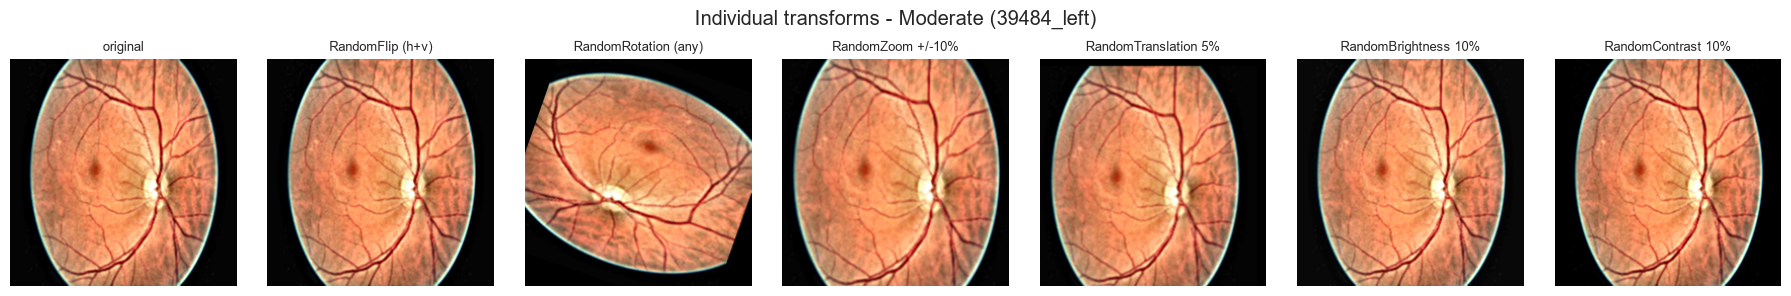

In [2]:
row = train_df[train_df.class_name == "Moderate"].sample(1, random_state=7).iloc[0]
img = pp.read_rgb(row.proc_path).astype("float32")
x = img[None]                                   # batch of 1

single = {
    "original":              None,
    "RandomFlip (h+v)":      layers.RandomFlip("horizontal_and_vertical", seed=1),
    "RandomRotation (any)":  layers.RandomRotation(0.5, fill_mode="constant", fill_value=0.0, seed=3),
    "RandomZoom +/-10%":     layers.RandomZoom(0.1, fill_mode="constant", fill_value=0.0, seed=5),
    "RandomTranslation 5%":  layers.RandomTranslation(0.05, 0.05, fill_mode="constant", fill_value=0.0, seed=2),
    "RandomBrightness 10%":  layers.RandomBrightness(0.1, value_range=(0, 255), seed=4),
    "RandomContrast 10%":    layers.RandomContrast(0.1, seed=6),
}
fig, axes = plt.subplots(1, len(single), figsize=(2.6 * len(single), 3))
for ax, (name, layer) in zip(axes, single.items()):
    out = x if layer is None else layer(x, training=True)
    ax.imshow(np.clip(np.asarray(out[0]), 0, 255).astype("uint8")); ax.set_title(name, fontsize=9); ax.axis("off")
plt.suptitle(f"Individual transforms - {row.class_name} ({row.image_id})"); plt.tight_layout()
utils.save_fig("03_augmentations_individual"); plt.show()

**Why these and not others**

| Transform | Kept? | Reason |
|---|---|---|
| Flip h/v, rotation any angle | yes | A fundus has no canonical orientation; left and right eyes are mirror images. Free, label-preserving diversity. |
| Zoom +/-10 %, translation 5 % | yes | Different cameras / field-of-view; retina not always centred. Small so lesions are not pushed out of frame. |
| Brightness / contrast +/-10 % | yes | Exposure differs between clinics (seen in EDA). Kept mild because CLAHE already normalised exposure. |
| Shear | **no** | Distorts microaneurysm / exudate shapes - changes the diagnostic cue. |
| Hue / saturation shift | **no** | Colour *is* the cue: haemorrhages are dark red, exudates yellow-white. |
| Cut-out / mixup | no | Could erase or blend the single tiny lesion that decides Mild vs No_DR. |

## 2. The full stack: one image, many augmented versions

saved C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures\03_augmentation_stack.png


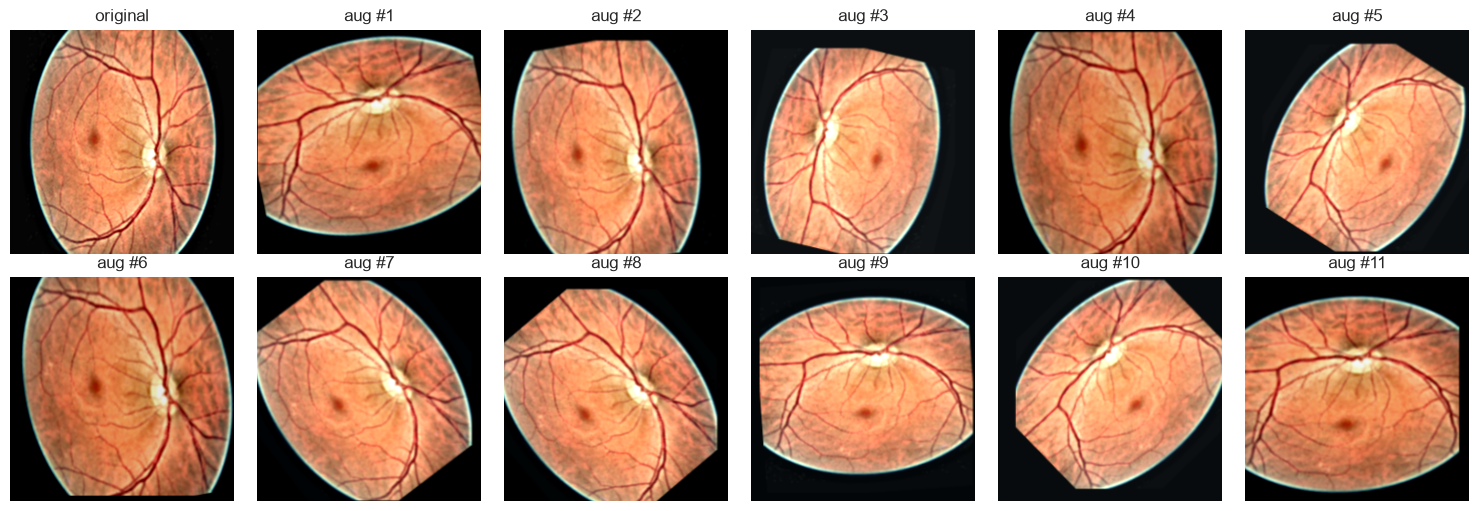

In [3]:
aug = dataset.build_augmenter(seed=config.SEED)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.2))
axes = axes.ravel()
axes[0].imshow(img.astype("uint8")); axes[0].set_title("original"); axes[0].axis("off")
for i in range(1, 12):
    out = np.asarray(aug(x, training=True)[0])
    axes[i].imshow(np.clip(out, 0, 255).astype("uint8")); axes[i].set_title(f"aug #{i}"); axes[i].axis("off")
plt.tight_layout(); utils.save_fig("03_augmentation_stack"); plt.show()

## 3. Class imbalance and class weights

In [4]:
counts = train_df.label.value_counts().sort_index()
cw = dataset.class_weights(train_df)
tbl = pd.DataFrame({"class": config.CLASS_NAMES, "train images": counts.values,
                    "share %": (counts / counts.sum() * 100).round(1).values,
                    "class weight": [round(cw[i], 2) for i in range(config.NUM_CLASSES)]})
display(tbl)
print("Loss contribution of one Proliferate_DR sample = "
      f"{cw[4] / cw[0]:.0f}x that of one No_DR sample")

,class,train images,share %,class weight
0,No_DR,18070,73.5,0.27
1,Mild,1708,6.9,2.88
2,Moderate,3704,15.1,1.33
3,Severe,611,2.5,8.05
4,Proliferate_DR,495,2.0,9.93


Loss contribution of one Proliferate_DR sample = 37x that of one No_DR sample


**Class weights** (`w_c = N / (K * n_c)`, sklearn 'balanced') multiply the loss of each sample
by the inverse frequency of its class. No data is duplicated; the model simply pays ~37x more
for a mistake on a PDR image than on a No_DR image. Cheap, standard, but with very large
weights the gradient can become noisy (a single rare-class batch dominates an update).

## 4. Oversampling strategies: what a training batch actually looks like

,natural (% of batch),sqrt (% of batch),balanced (% of batch)
No_DR,73.5,47.4,20.0
Mild,6.9,14.6,20.0
Moderate,15.1,21.5,20.0
Severe,2.5,8.7,20.0
Proliferate_DR,2.0,7.8,20.0


saved C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures\03_sampling_strategies.png


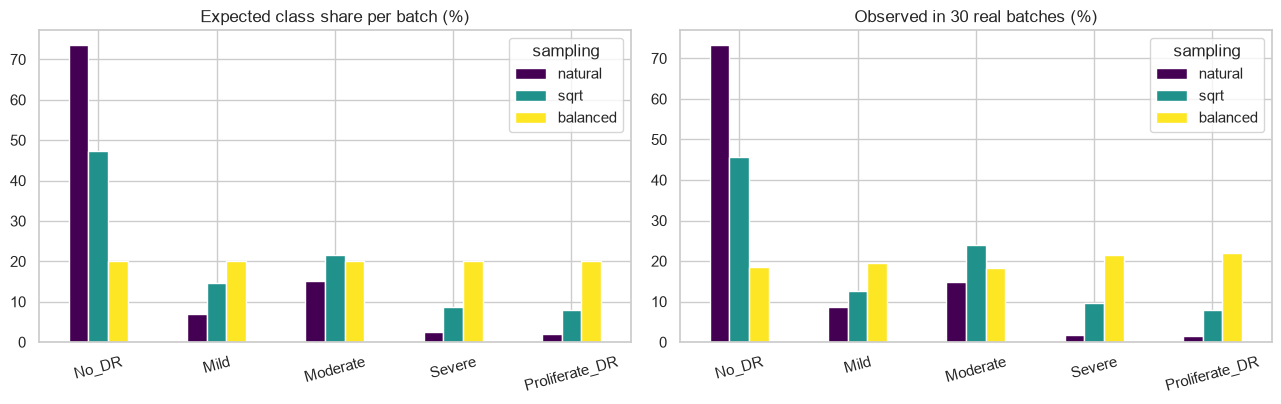

In [5]:
strategies = ["natural", "sqrt", "balanced"]
weights = pd.DataFrame({s: dataset.sampling_weights(train_df, s) for s in strategies},
                       index=config.CLASS_NAMES)
display((weights * 100).round(1).rename(columns=lambda c: f"{c} (% of batch)"))

# Draw 30 real batches from each pipeline and count labels -> empirical batch composition
observed = {}
for s in strategies:
    ds = dataset.make_dataset(train_df, batch_size=32, sampling=s, shuffle=True, augment=False)
    labs = np.concatenate([y.numpy() for _, y in ds.take(30)])
    observed[s] = np.bincount(labs, minlength=config.NUM_CLASSES) / len(labs)
observed = pd.DataFrame(observed, index=config.CLASS_NAMES)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
(weights * 100).plot(kind="bar", ax=ax[0], colormap="viridis"); ax[0].set_title("Expected class share per batch (%)")
(observed * 100).plot(kind="bar", ax=ax[1], colormap="viridis"); ax[1].set_title("Observed in 30 real batches (%)")
for a in ax: a.set_xlabel(""); a.tick_params(axis="x", rotation=15); a.legend(title="sampling")
plt.tight_layout(); utils.save_fig("03_sampling_strategies"); plt.show()

**Interpretation.**
* *natural*: 3 of 4 images in every batch are healthy; Severe/PDR appear <1 image per batch -
  the network barely sees them.
* *balanced*: every class 20 % - but PDR has only ~500 training images, so each is repeated
  ~35x per epoch relative to No_DR; heavy augmentation is what prevents memorisation.
* *sqrt*: middle ground (rare classes ~8 % each, No_DR still the plurality). Fewer duplicates
  than balanced, far more minority exposure than natural.

The training notebook will compare **class-weights** vs **sqrt oversampling** vs
**no balancing** on the validation set and pick the winner with numbers, not intuition.

## 5. Effective dataset size and pipeline throughput

In [6]:
# With augmentation every epoch shows a *different* version of each image.
print(f"Distinct raw training images : {len(train_df):,}")
print(f"Images seen over 30 epochs    : {30 * len(train_df):,} (all different after augmentation)")

for name, kw in [("val (no aug)", dict(augment=False)), ("train (aug, sqrt sampling)", dict(augment=True, shuffle=True, sampling="sqrt"))]:
    ds = dataset.make_dataset(train_df, batch_size=32, **kw)
    next(iter(ds))                                   # warm-up
    t = time.time(); n = sum(len(y) for _, y in ds.take(25))
    print(f"{name:28s}: {n / (time.time() - t):6.0f} images/s")

Distinct raw training images : 24,588
Images seen over 30 epochs    : 737,640 (all different after augmentation)


val (no aug)                :   1686 images/s


train (aug, sqrt sampling)  :    512 images/s


Even on CPU the input pipeline delivers a few hundred images per second, well above what a
single GPU consumes for a 224 px EfficientNet (~150-300 img/s in training), so training
is compute-bound, not I/O-bound. Preprocessing offline (notebook 02) is what makes this possible.

## 6. Summary for the report

* **Augmentation:** flip h/v, rotation (any angle), zoom 10 %, translation 5 %, brightness 10 %,
  contrast 10 % - all label-preserving for fundus images; shear / hue / cut-out deliberately excluded.
  Applied on-the-fly in `tf.data`, so every epoch sees new variants (effective dataset size x epochs).
* **Imbalance (36x):** two remedies implemented - inverse-frequency class weights and
  batch-level oversampling (sqrt or fully balanced). Chosen empirically in notebook 04.
* **Evidence:** per-transform figure, augmentation-stack figure, class-weight table,
  expected-vs-observed batch composition figure, throughput numbers.